# Detección de rostros con OpenCV y Haar Cascade


El siguiente código utiliza un clasificador tipo Haar Cascade para detectar rostros en una imagen en escala de grises usando OpenCV:

```python
# Siempre se debe pasar antes a escala de grises, ya que el detector no interpreta el color
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)
```


## ¿Qué devuelve?

`faces` es una lista de rectángulos, donde cada uno representa un rostro detectado:

```python
(x, y, w, h)
```

- `x, y`: esquina superior izquierda
- `w`: ancho del rostro
- `h`: alto del rostro

## Parámetros

### `scaleFactor=1.1`

Define cuánto se reduce la imagen en cada escala.

- Valores cercanos a 1, por ejemplo `1.05`, dan mayor precisión, pero hacen que el proceso sea más lento.
- Valores mayores, por ejemplo `1.3`, hacen el proceso más rápido, pero menos preciso.

Esto permite detectar rostros de distintos tamaños en una misma imagen. Por ejemplo cuando una persona está más cerca y otra más lejos.

---

### `minNeighbors=5`

Indica cuántas detecciones cercanas deben coincidir para confirmar que realmente hay un rostro.

- Un valor bajo, como `3`, genera más detecciones, pero también más falsos positivos.
- Un valor alto, como `6` o `7`, vuelve al detector más estricto.

`minNeighbors` se ve influenciado cuando hay varias caras juntas, porque este parámetro controla cuántas detecciones solapadas deben coincidir para validar un rostro. Cuando las caras están bien separadas, no hay problema, pero si están muy cerca o parcialmente superpuestas, las detecciones pueden mezclarse, haciendo que algunas caras se pierdan si minNeighbors es alto o que aparezcan falsos positivos si es bajo. En escenas con grupos o multitudes, conviene usar valores más bajos para no perder rostros, aunque esto aumenta el ruido, por lo que siempre hay que equilibrarlo según la densidad y calidad de la imagen.

---

### `minSize=(30, 30)`

Define el tamaño mínimo del objeto a detectar.

- Evita detectar ruido o rostros demasiado pequeños.
- Este valor está expresado en píxeles.

## Consideraciones al variar la resolución de la imagen

### 1. `minSize` debe ajustarse según la resolución

Cuando cambia la resolución de la imagen, el tamaño de los rostros en píxeles también cambia.

- En imágenes pequeñas, por ejemplo `320x240`, conviene usar un `minSize` pequeño, como `(20, 20)`.
- En imágenes grandes, por ejemplo `1920x1080`, conviene usar un `minSize` mayor, como `(60, 60)` o más.

Si no ajustas este parámetro:

- Podrías perder rostros pequeños si el valor es demasiado grande.
- Podrías detectar ruido si el valor es demasiado pequeño.

### 2. Mayor resolución implica mayor costo computacional

Si aumentas la resolución, también aumenta la cantidad de píxeles que el algoritmo debe analizar.

- Mayor resolución implica mayor tiempo de procesamiento.
- Esto es especialmente importante en aplicaciones en tiempo real, como webcam o video.

Una práctica común es reducir la resolución antes de detectar:

```python
small = cv2.resize(gray, (0, 0), fx=0.5, fy=0.5)
faces = face_cascade.detectMultiScale(small, ...)
```

Después, si necesitas dibujar los rectángulos sobre la imagen original, debes reescalar las coordenadas.

### 3. `scaleFactor` también depende de la resolución

La resolución influye en cuántas escalas conviene explorar.

- En imágenes grandes, puedes usar un `scaleFactor` más alto, como `1.2`, para acelerar la detección.
- En imágenes pequeñas, conviene usar un `scaleFactor` más bajo, como `1.05`, para no saltarte posibles rostros.

Un `scaleFactor` demasiado alto puede hacer que se omitan caras cuyo tamaño quede entre dos escalas evaluadas.

### 4. La calidad visual también importa

No solo importa la resolución, sino también la nitidez, el ruido y la iluminación de la imagen.

- Si la imagen es borrosa o de baja calidad, puede ser necesario bajar `minNeighbors` para no perder detecciones.
- Si la imagen es clara y de buena calidad, puedes usar valores más estrictos para reducir falsos positivos.

### 5. La distancia del rostro a la cámara cambia su tamaño aparente

Aunque la resolución sea la misma, una cara lejana ocupará menos píxeles que una cercana.

Por eso, si en tus imágenes hay personas a distintas distancias:

- Usa un `minSize` lo suficientemente pequeño para no perder rostros lejanos.
- Pero no tan pequeño como para que aparezcan muchas detecciones falsas.

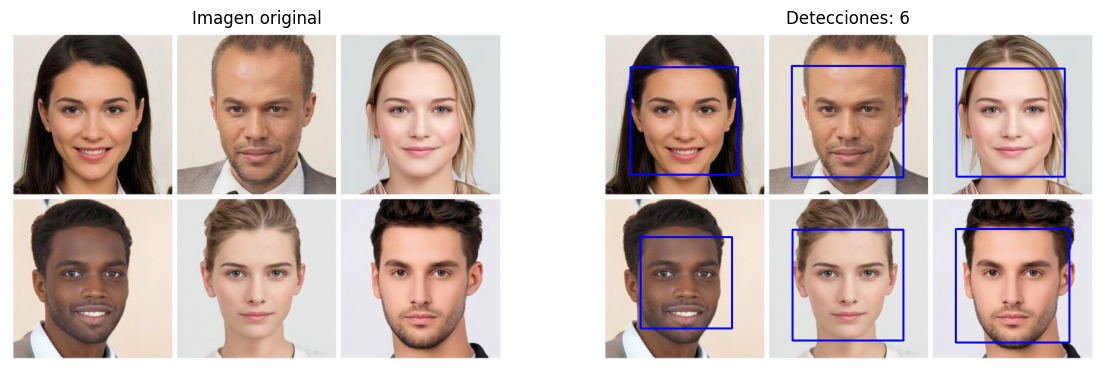

Imagen de salida guardada en: salida_detec.jpg


In [57]:
import cv2
import os
import matplotlib.pyplot as plt

input_path = "foto2.jpg"
output_path = "salida_detec.jpg"

cascade_path = os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml")
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError(f"No se pudo cargar el clasificador en: {cascade_path}")

image = cv2.imread(input_path)
if image is None:
    raise FileNotFoundError(f"No se pudo leer la imagen en: {input_path}")

original = image.copy()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

h_img, w_img = image.shape[:2]
for (x, y, w, h) in faces:
    side = max(w, h)

    cx = x + w // 2
    cy = y + h // 2
    x1 = cx - side // 2
    y1 = cy - side // 2
    x2 = x1 + side
    y2 = y1 + side

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w_img - 1, x2)
    y2 = min(h_img - 1, y2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

cv2.imwrite(output_path, image)

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Detecciones: {len(faces)}")
plt.axis('off')

plt.show()

print(f"Imagen de salida guardada en: {output_path}")

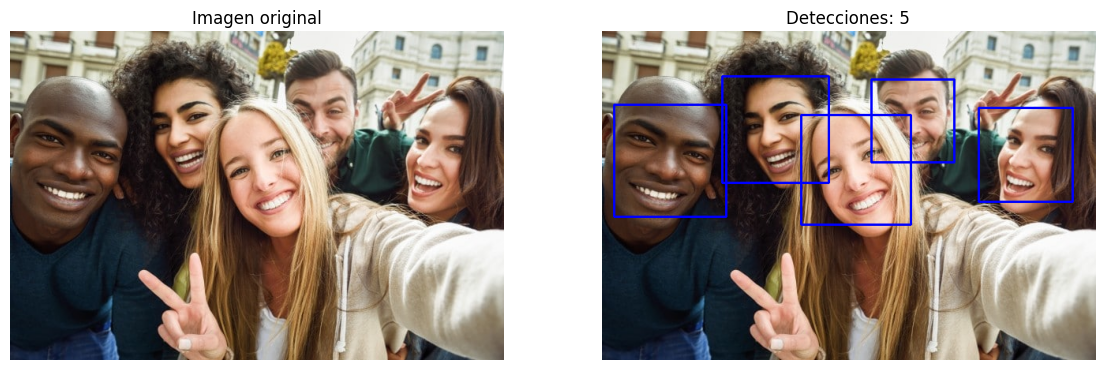

Imagen de salida guardada en: salida_detec.jpg


In [56]:
import cv2
import os
import matplotlib.pyplot as plt

input_path = "foto1.jpg"
output_path = "salida_detec.jpg"

cascade_path = os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml")
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError(f"No se pudo cargar el clasificador en: {cascade_path}")

image = cv2.imread(input_path)
if image is None:
    raise FileNotFoundError(f"No se pudo leer la imagen en: {input_path}")

original = image.copy()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.01, # Elijo un valor más pequeño para más precisión
    minNeighbors=6,
    minSize=(40, 40)
)

h_img, w_img = image.shape[:2]
for (x, y, w, h) in faces:
    side = max(w, h)

    cx = x + w // 2
    cy = y + h // 2
    x1 = cx - side // 2
    y1 = cy - side // 2
    x2 = x1 + side
    y2 = y1 + side

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w_img - 1, x2)
    y2 = min(h_img - 1, y2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

cv2.imwrite(output_path, image)

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Detecciones: {len(faces)}")
plt.axis('off')

plt.show()

print(f"Imagen de salida guardada en: {output_path}")